In [21]:
import pandas as pd
import praw
import os
from dotenv import load_dotenv
import re
import spacy
import pickle
from tensorflow.keras.models import load_model

I0000 00:00:1776252657.296784   53850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776252657.522081   53850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776252659.370734   53850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Test Conn

In [3]:
load_dotenv()

reddit = praw.Reddit(
    client_id=os.getenv("CLIENT_ID"),
    client_secret=os.getenv("TOKEN_REDDIT"),
    user_agent=('sentiment_model.keras')
)

# Test de connexion
print(reddit.read_only)

True


## Extract 

In [4]:
subreddit = reddit.subreddit('movies')

commentaires = []

# Récupère les 100 posts les plus récents
for post in subreddit.hot(limit=100):
    post.comments.replace_more(limit=0)  # charge tous les commentaires
    for comment in post.comments.list():
        commentaires.append({
            'post_title': post.title,
            'comment'   : comment.body,
            'score'     : comment.score,
            'date'      : comment.created_utc
        })


df_reddit = pd.DataFrame(commentaires)
print(f"{len(df_reddit):,} commentaires récupérés")
df_reddit.head()
df_reddit.to_csv('./asset/reddit_comments.csv', index=False)

14,077 commentaires récupérés


## Traitement

In [10]:
df_reddit = pd.read_csv("./asset/reddit_comments.csv")

In [11]:
df_reddit

,post_title,comment,score,date
0,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,"Update: Ben's AMA post is now live here, pleas...",1,1.774047e+09
1,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,GEE CEE PEE DEE.,81,1.774051e+09
2,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I never watched The OC and it's crazy to see b...,28,1.774047e+09
3,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,The OC was a great show.,21,1.774060e+09
4,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I like this guy. He did a one man show of John...,16,1.774048e+09
...,...,...,...,...
14072,How Practical Sets and VFX combine on Mickey 17,The ice cave renders were so complex they had ...,1,1.776169e+09
14073,How Practical Sets and VFX combine on Mickey 17,[removed],-17,1.776165e+09
14074,How Practical Sets and VFX combine on Mickey 17,"Book was mediocre, movie was terrible \n\nPret...",3,1.776191e+09
14075,How Practical Sets and VFX combine on Mickey 17,I walked out after 40 minutes,2,1.776186e+09


In [12]:
def clean_reddit(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)         # URLs
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)           # liens markdown [texte](url)
    text = re.sub(r'\*\*|__|\*|_|~~|`', '', text)        # formatage markdown
    text = re.sub(r'&gt;.*?\n', '', text)                # citations Reddit (>)
    text = re.sub(r'/r/\w+|/u/\w+', '', text)            # mentions subreddit/user
    text = re.sub(r'\n+', ' ', text)                     # sauts de ligne
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # caractères spéciaux
    text = re.sub(r'\s+', ' ', text).strip().lower()     # espaces multiples
    return text
df_reddit['comment_clean'] = df_reddit['comment'].apply(clean_reddit)

In [13]:
df_reddit

,post_title,comment,score,date,comment_clean
0,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,"Update: Ben's AMA post is now live here, pleas...",1,1.774047e+09,update bens ama post is now live here please h...
1,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,GEE CEE PEE DEE.,81,1.774051e+09,gee cee pee dee
2,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I never watched The OC and it's crazy to see b...,28,1.774047e+09,i never watched the oc and its crazy to see ba...
3,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,The OC was a great show.,21,1.774060e+09,the oc was a great show
4,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I like this guy. He did a one man show of John...,16,1.774048e+09,i like this guy he did a one man show of johnn...
...,...,...,...,...,...
14072,How Practical Sets and VFX combine on Mickey 17,The ice cave renders were so complex they had ...,1,1.776169e+09,the ice cave renders were so complex they had ...
14073,How Practical Sets and VFX combine on Mickey 17,[removed],-17,1.776165e+09,removed
14074,How Practical Sets and VFX combine on Mickey 17,"Book was mediocre, movie was terrible \n\nPret...",3,1.776191e+09,book was mediocre movie was terrible pretty di...
14075,How Practical Sets and VFX combine on Mickey 17,I walked out after 40 minutes,2,1.776186e+09,i walked out after minutes


In [14]:
df_reddit = df_reddit[df_reddit['comment_clean'].str.len() > 10].reset_index(drop=True)

print(f"Après nettoyage : {len(df_reddit):,} commentaires")
df_reddit[['comment', 'comment_clean']].head(5)

Après nettoyage : 13,268 commentaires


,comment,comment_clean
0,"Update: Ben's AMA post is now live here, pleas...",update bens ama post is now live here please h...
1,GEE CEE PEE DEE.,gee cee pee dee
2,I never watched The OC and it's crazy to see b...,i never watched the oc and its crazy to see ba...
3,The OC was a great show.,the oc was a great show
4,I like this guy. He did a one man show of John...,i like this guy he did a one man show of johnn...


In [15]:
df_reddit

,post_title,comment,score,date,comment_clean
0,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,"Update: Ben's AMA post is now live here, pleas...",1,1.774047e+09,update bens ama post is now live here please h...
1,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,GEE CEE PEE DEE.,81,1.774051e+09,gee cee pee dee
2,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I never watched The OC and it's crazy to see b...,28,1.774047e+09,i never watched the oc and its crazy to see ba...
3,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,The OC was a great show.,21,1.774060e+09,the oc was a great show
4,AMA/Q&A Announcement - Ben McKenzie - Tuesday ...,I like this guy. He did a one man show of John...,16,1.774048e+09,i like this guy he did a one man show of johnn...
...,...,...,...,...,...
13263,How Practical Sets and VFX combine on Mickey 17,Practical sets give the actors real spaces to ...,2,1.776164e+09,practical sets give the actors real spaces to ...
13264,How Practical Sets and VFX combine on Mickey 17,The ice cave renders were so complex they had ...,1,1.776169e+09,the ice cave renders were so complex they had ...
13265,How Practical Sets and VFX combine on Mickey 17,"Book was mediocre, movie was terrible \n\nPret...",3,1.776191e+09,book was mediocre movie was terrible pretty di...
13266,How Practical Sets and VFX combine on Mickey 17,I walked out after 40 minutes,2,1.776186e+09,i walked out after minutes


## Traitement NLP

In [18]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [19]:
processed = []
for doc in nlp.pipe(df_reddit['comment_clean'].tolist(), batch_size=500, n_process=-1):
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.is_alpha
        and len(token.text) > 1
    ]
    processed.append(' '.join(tokens))

df_reddit['comment_nlp'] = processed
df_reddit = df_reddit[df_reddit['comment_nlp'].str.len() > 0].reset_index(drop=True)
print(f"Après NLP : {len(df_reddit):,} commentaires")

Après NLP : 13,228 commentaires


## Vectrorisation + Predict

In [23]:
with open('vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

model = load_model('sentiment_model.keras')

In [24]:
X_reddit = vectorizer(df_reddit['comment_nlp'].values)
predictions = model.predict(X_reddit)

414/414 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
df_reddit['score_sentiment'] = predictions
df_reddit['sentiment']       = (predictions > 0.5).astype(int)
df_reddit['sentiment_label'] = df_reddit['sentiment'].map({0: 'Négatif', 1: 'Positif'})

print(df_reddit[['comment', 'sentiment_label', 'score_sentiment']].head(10))

                                             comment sentiment_label  \
0  Update: Ben's AMA post is now live here, pleas...         Positif   
1                                   GEE CEE PEE DEE.         Négatif   
2  I never watched The OC and it's crazy to see b...         Positif   
3                          The OC was a great show.          Positif   
4  I like this guy. He did a one man show of John...         Positif   
5     The OC was THE show during my highschool years         Positif   
6  Dang, you probably [missed out on this gem](ht...         Négatif   
7  He is so so underrated in Junebug. His perform...         Positif   
8                       Really liked him in Gotham.          Positif   
9                            Your are a good actor.          Positif   

   score_sentiment  
0         0.836025  
1         0.270379  
2         0.787278  
3         0.940270  
4         0.617523  
5         0.529017  
6         0.269894  
7         0.821596  
8         0.606918

In [26]:
# Analyse des tendances
print("=== TENDANCES GLOBALES ===")
print(df_reddit['sentiment_label'].value_counts())
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

=== TENDANCES GLOBALES ===
sentiment_label
Positif    7794
Négatif    5434
Name: count, dtype: int64

sentiment_label
Positif    58.9%
Négatif    41.1%
Name: proportion, dtype: str


In [28]:
df_reddit.to_csv("./asset/clean_nlp_comment_reddit.csv")

=== TENDANCES GLOBALES ===
sentiment_label
Positif    7794
Négatif    5434
Name: count, dtype: int64

sentiment_label
Positif    58.9%
Négatif    41.1%
Name: proportion, dtype: str

=== TOP 10 POSTS ===
                                                    total  positifs  negatifs  \
post_title                                                                      
Sony Pictures Boss Tom Rothman Urges Theater Ow...    491       264       227   
What old movies (let's say pre-1980) made lots ...    481       312       169   
Was Congo Really That Bad?                            475       314       161   
Joaquin Phoenix, Ben Stiller, Kristen Stewart a...    467       221       246   
The Hunger Games: Sunrise on the Reaping | Offi...    466       322       144   
“The Legend of Zelda” movie has wrapped filming       465       288       177   
Official Posters for 'Spider-Man: Brand New Day'      457       272       185   
New poster for ‘Coyote vs. Acme.’ In theaters A...    452       243 

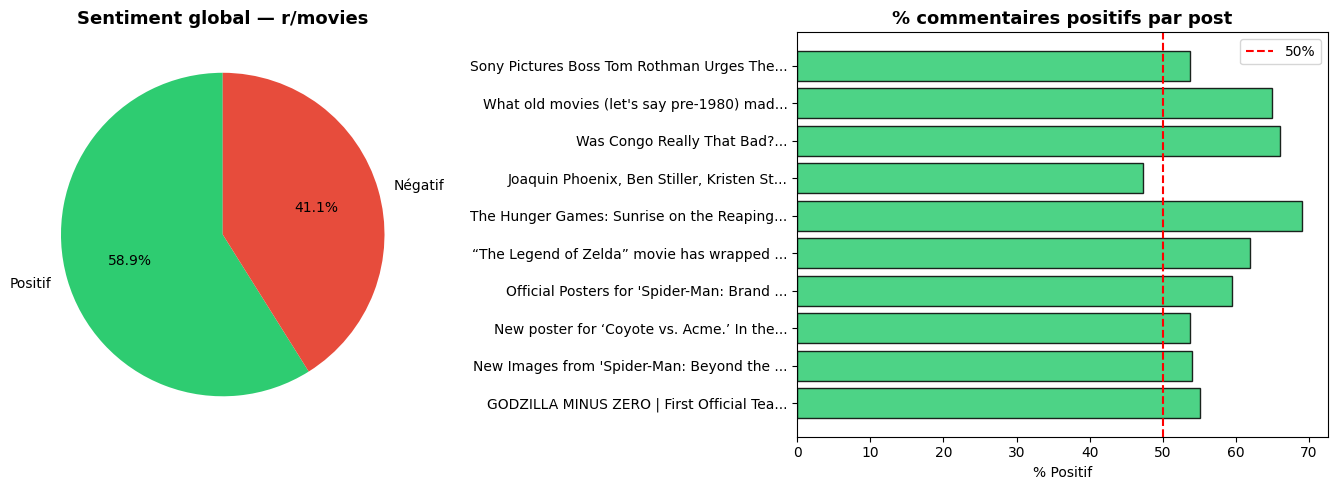

In [29]:

import matplotlib.pyplot as plt

# Distribution globale
print("=== TENDANCES GLOBALES ===")
counts = df_reddit['sentiment_label'].value_counts()
print(counts)
print()
print(df_reddit['sentiment_label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart global
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Sentiment global — r/movies', fontsize=13, fontweight='bold')

# Top 10 posts par nb de commentaires + leur sentiment
top_posts = df_reddit.groupby('post_title').agg(
    total     = ('sentiment_label', 'count'),
    positifs  = ('sentiment_label', lambda x: (x == 'Positif').sum()),
    negatifs  = ('sentiment_label', lambda x: (x == 'Négatif').sum()),
).sort_values('total', ascending=False).head(10)

top_posts['ratio_positif'] = (top_posts['positifs'] / top_posts['total'] * 100).round(1)
print("\n=== TOP 10 POSTS ===")
print(top_posts)

# Barplot ratio positif par post
short_titles = [t[:40] + '...' for t in top_posts.index]
axes[1].barh(short_titles[::-1], top_posts['ratio_positif'][::-1],
             color='#2ecc71', edgecolor='black', alpha=0.85)
axes[1].axvline(x=50, color='red', linestyle='--', label='50%')
axes[1].set_title('% commentaires positifs par post', fontsize=13, fontweight='bold')
axes[1].set_xlabel('% Positif')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse_reddit.png', dpi=150, bbox_inches='tight')
plt.show()